In [1]:
!curl -L "https://drive.google.com/u/1/uc?id=1DgD3Ue7P1m5nb0ssn2f2nMsfkYtZVuK3&export=download" --output dataset.zip
! yes | unzip dataset.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 21.3M  100 21.3M    0     0  5816k      0  0:00:03  0:00:03 --:--:-- 9323k
Archive:  dataset.zip
  inflating: holidays_events.csv     
  inflating: oil.csv                 
  inflating: sample_submission.csv   
  inflating: stores.csv              
  inflating: test.csv                
  inflating: train.csv               
  inflating: transactions.csv        


In [2]:
!pip install darts --quiet
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from datetime import datetime, timedelta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 884.7/884.7 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 28.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.5/160.5 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 22.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.8/121.8 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.2/802.2 kB 9.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 15.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.8/279.8 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB

In [3]:
from darts import TimeSeries
from tqdm import tqdm
import os

In [9]:
if os.path.exists('/kaggle/input/store-sales-time-series-forecasting/'):
  folder = "/kaggle/input/store-sales-time-series-forecasting/"
else:
  folder = ""

In [11]:
df_train_full = pd.read_csv(f"{folder}train.csv", parse_dates=['date'])
df_test_full = pd.read_csv(f"{folder}test.csv", parse_dates=['date'])
df_stores = pd.read_csv(f"{folder}stores.csv").set_index('store_nbr')
df_oil = pd.read_csv(f"{folder}oil.csv", parse_dates=['date'])
df_holidays_events = pd.read_csv(f"{folder}holidays_events.csv", parse_dates=['date'])
df_transactions_full = pd.read_csv(f"{folder}transactions.csv")
df_sample_submission = pd.read_csv(f"{folder}sample_submission.csv")

In [12]:
# Uncomment these two lines when generating final result
# experimental_family = df_train_full.family.unique()
# experimental_stores = df_train_full.store_nbr.unique()

experimental_family = ['AUTOMOBILE', 'BOOKS', 'BEVERAGES', 'FROZEN FOODS', 'LIQUOR,WINE,BEER']
experimental_stores = [10, 15, 20, 25, 30] # Pick store 25 intentionally because it opens on 1st of January while other shops are not opening on that day


df_train = df_train_full[
    (df_train_full.family.isin(experimental_family)) &
    (df_train_full.store_nbr.isin(experimental_stores))
]

df_test = df_test_full[
    (df_test_full.family.isin(experimental_family)) &
    (df_test_full.store_nbr.isin(experimental_stores))
]

df_transactions = df_transactions_full[
    df_transactions_full.store_nbr.isin(experimental_stores)
]

In [13]:
family_list = df_train['family'].unique()
store_list = df_train['store_nbr'].unique()

# 1. Static covariates - Store information

In [14]:
X = df_train.join(df_stores, on ='store_nbr')
X = X.sort_values(["store_nbr","family","date"])
X = X.astype({"store_nbr":'str', "family":'str', "city":'str', "state":'str', "type":'str', "cluster":'str'})

X.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster
36,36,2013-01-01,10,BEVERAGES,0.0,0,Quito,Pichincha,C,15
1818,1818,2013-01-02,10,BEVERAGES,396.0,0,Quito,Pichincha,C,15
3600,3600,2013-01-03,10,BEVERAGES,399.0,0,Quito,Pichincha,C,15
5382,5382,2013-01-04,10,BEVERAGES,460.0,0,Quito,Pichincha,C,15
7164,7164,2013-01-05,10,BEVERAGES,624.0,0,Quito,Pichincha,C,15


# 2. Prepare the Darts TimeSeries

Here we prepare TS for each family, each store.

`family_TS_dict` is a dictionary of dictionary:

```python
{
    "BEVERAGE": {
        10: TimeSeries,
        20: TimeSeries,
    },
    "BOOKS": {
        10: TimeSeries,
        20: TimeSeries,
    },
}
```

Note that a darts TimeSeries is not just values, it also contains the covariates like "city","state","type","cluster".

Also, a darts TimeSeries can contain multiple time series.

In [15]:
family_TS_dict = {}

for family in tqdm(family_list):
    X_of_family = X.loc[X['family'] == family]

    list_of_TS_per_store = TimeSeries.from_group_dataframe(
                                X_of_family,
                                time_col="date",
                                group_cols=["store_nbr"], # columns for grouping time series
                                static_cols=["family", "city","state","type","cluster"], # static covariates
                                value_cols="sales", # target
                                fill_missing_dates=True, # filling missing dates, remember Dec 25th
                                freq='D' # days
                                )

    # In static coveriates values, the sequence is "store_nbr", "family", "city", "state", "type", "cluster"
    # So to get the store_number, we use ts.static_covariates_values()[0,0]

    family_TS_dict[family] = {
        int(ts.static_covariates_values()[0,0]): ts
        for ts in list_of_TS_per_store
    }


100%|██████████| 4/4 [00:00<00:00, 10.50it/s]


In [19]:
family_TS_dict["BEVERAGES"][30]#.pd_dataframe().head(3)

<TimeSeries (DataArray) (date: 1688, component: 1, sample: 1)>
array([[[   0.]],

       [[ 377.]],

       [[ 566.]],

       ...,

       [[1517.]],

       [[1175.]],

       [[4052.]]])
Coordinates:
  * date       (date) datetime64[ns] 2013-01-01 2013-01-02 ... 2017-08-15
  * component  (component) object 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  static_covariates store_nbr     family       city   s...
    hierarchy:          None

In [18]:
# To check the dataframe behind the scene, use pd_dataframe() function.

family_TS_dict["BEVERAGES"][30].pd_dataframe()

component,sales
date,
2013-01-01,0.0
2013-01-02,377.0
2013-01-03,566.0
2013-01-04,370.0
2013-01-05,447.0
...,...
2017-08-11,1086.0
2017-08-12,1454.0
2017-08-13,1517.0


# 3. Transform the TS

We need some preprocessing about the TS:

1. Fill na
2. Convert the categorical variables from strings to numbers
3. Taking log
4. Min-max scaling

Individual transformation is made for each family. Each of them is trained with n sets of time series (n=number of stores).

In [20]:
from darts.dataprocessing import Pipeline
from darts.dataprocessing.transformers import Scaler, StaticCovariatesTransformer, MissingValuesFiller, InvertibleMapper
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

In [22]:
family_pipeline_dict = {}
family_TS_transformed_dict = {}

for family in tqdm(family_list):
    train_filler = MissingValuesFiller(verbose=False, n_jobs=-1, name="Fill NAs")
    static_cov_transformer = StaticCovariatesTransformer(verbose=False, transformer_cat = OrdinalEncoder(), name="Encoder")
    log_transformer = InvertibleMapper(np.log1p, np.expm1, verbose=False, n_jobs=-1, name="Log-Transform")
    train_scaler = Scaler(scaler=MinMaxScaler(), verbose=False, n_jobs=-1, name="Scaling")

    transform_pipeline = Pipeline([
        train_filler,
        static_cov_transformer,
        log_transformer,
        train_scaler
    ])

    training_transformed = transform_pipeline.fit_transform(family_TS_dict[family].values())
    family_pipeline_dict[family] = transform_pipeline
    family_TS_transformed_dict[family] = dict(zip(family_TS_dict[family].keys(), training_transformed))

100%|██████████| 4/4 [00:05<00:00,  1.38s/it]


In [ ]:
family_TS_transformed_dict["BEVERAGES"][10].pd_dataframe().tail(3)

component,sales
date,
2017-08-13,0.928387
2017-08-14,0.890258
2017-08-15,0.935012


# 4. Create a set of datetime attributes

A table to contain the components of date.

1. Year
2. Month
3. day
4. day of year
5. day of week
6. week of year
7. Days since day 0

Then transform each column with min-max scalar.

In [26]:
from darts.utils.timeseries_generation import datetime_attribute_timeseries

In [27]:
full_time_period = pd.date_range(start=df_train['date'].min(), end=df_test['date'].max(), freq='D')

year = datetime_attribute_timeseries(time_index = full_time_period, attribute='year')
month = datetime_attribute_timeseries(time_index= full_time_period, attribute='month')
day = datetime_attribute_timeseries(time_index = full_time_period, attribute='day')
dayofyear = datetime_attribute_timeseries(time_index = full_time_period, attribute = 'dayofyear')
weekday = datetime_attribute_timeseries(time_index = full_time_period , attribute='dayofweek')
weekofyear = datetime_attribute_timeseries(time_index = full_time_period, attribute='weekofyear')
timesteps = TimeSeries.from_times_and_values(times = full_time_period,
                                            values = np.arange(len(full_time_period)),
                                            columns= ['linear_increase'])

time_cov = year.stack(month).stack(day).stack(dayofyear).stack(weekday).stack(weekofyear).stack(timesteps)
time_cov = time_cov.astype(np.float32)

In [28]:
time_cov.pd_dataframe()

component,year,month,day,dayofyear,dayofweek,weekofyear,linear_increase
time,,,,,,,
2013-01-01,2013.0,0.0,0.0,0.0,1.0,0.0,0.0
2013-01-02,2013.0,0.0,1.0,1.0,2.0,0.0,1.0
2013-01-03,2013.0,0.0,2.0,2.0,3.0,0.0,2.0
2013-01-04,2013.0,0.0,3.0,3.0,4.0,0.0,3.0
2013-01-05,2013.0,0.0,4.0,4.0,5.0,0.0,4.0
...,...,...,...,...,...,...,...
2017-08-27,2017.0,7.0,26.0,238.0,6.0,33.0,1699.0
2017-08-28,2017.0,7.0,27.0,239.0,0.0,34.0,1700.0
2017-08-29,2017.0,7.0,28.0,240.0,1.0,34.0,1701.0


In [29]:
time_cov_scaler = Scaler(verbose=False, n_jobs=-1, name="Scaler")
time_cov_transformed = time_cov_scaler.fit_transform(time_cov)

In [30]:
time_cov_transformed.pd_dataframe().tail(3)

component,year,month,day,dayofyear,dayofweek,weekofyear,linear_increase
time,,,,,,,
2017-08-29,1.0,0.636364,0.933333,0.657534,0.166667,0.653846,0.998826
2017-08-30,1.0,0.636364,0.966667,0.660274,0.333333,0.653846,0.999413
2017-08-31,1.0,0.636364,1.000000,0.663014,0.500000,0.653846,1.000000


# 5. Oil price

<Axes: >

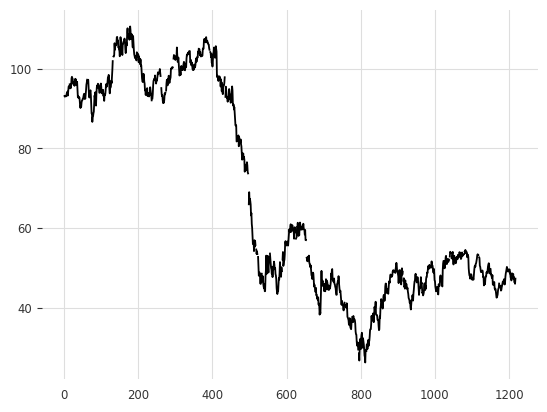

In [31]:
df_oil['dcoilwtico'].plot()

For oil price, we need to fill na -- it has quite a lot of null values.

Let's preprocess the time series with
1. Fill na
2. Min-max scalar

Also, we want to add moving averages as additional information

1. MA 7
2. MA 28

In [32]:
from darts.models.filtering.moving_average_filter import MovingAverageFilter

In [38]:
oil = TimeSeries.from_dataframe(df_oil,
                                time_col = 'date',
                                value_cols = ['dcoilwtico'],
                                freq = 'D')

# Transform
oil_filler = MissingValuesFiller(verbose=False, n_jobs=-1, name="Filler")
oil_scaler = Scaler(verbose=False, n_jobs=-1, name="Scaler")
oil_pipeline = Pipeline([oil_filler, oil_scaler])
oil_transformed = oil_pipeline.fit_transform(oil)

# Moving Averages for Oil Price
oil_moving_average_7 = MovingAverageFilter(window=7)
oil_moving_average_28 = MovingAverageFilter(window=28)

ma_7 = oil_moving_average_7.filter(oil_transformed)
ma_7 = ma_7.with_columns_renamed(col_names=ma_7.components, col_names_new='oil_ma_7')

ma_28 = oil_moving_average_28.filter(oil_transformed)
ma_28 = ma_28.with_columns_renamed(col_names=ma_28.components, col_names_new='oil_ma_28')

oil_ts = oil_transformed.stack(ma_7).stack(ma_28).astype(np.float32)

In [39]:
oil_ts.pd_dataframe().head(3)

component,dcoilwtico,oil_ma_7,oil_ma_28
date,,,
2013-01-01,0.792965,0.792402,0.796154
2013-01-02,0.792965,0.792530,0.796036
2013-01-03,0.790951,0.792668,0.796688


# 6. Holidays

In [40]:
# There can be one multiple events on one day

df_holidays_events[df_holidays_events['date'] == '2014-06-25']

,date,type,locale,locale_name,description,transferred
110,2014-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
111,2014-06-25,Holiday,Local,Machala,Fundacion de Machala,False
112,2014-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
113,2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False


1. National holidays are identified by type Holiday and the locale is National
2. Earthquake relief is identified by 'Terremoto Manabi' in the description
3. Christmas is identified by 'Navidad' in the description
4. Football event is identified by 'fulbol' in the description
5. National event is identifited by type Event and the locale is National, but take away earthquake and football
6. Work day is identified by type "Work Day"
7. Local holiday --- this is the funny part, since different stores are located in different region, here we identify a set of holiday per store.  We need to match the locale name with the state or the city of the holidays.

Task here is to create holiday TS (looks pretty much like a table, with 1 row = 1 day).

The TimeSeries object contains 7 time series (like 7 columns) of information listed above.

In [41]:
holiday_TS_per_store = {}

for store_nbr in store_list:
    temp = df_holidays_events[["date"]].copy()

    temp["national_holiday"] = (
        (df_holidays_events["type"] == "Holiday") &
        (df_holidays_events["locale"] == "National")
    ) * 1

    temp["earthquake_relief"] = df_holidays_events['description'].str.contains('Terremoto Manabi') * 1

    temp["christmas"] = df_holidays_events['description'].str.contains('Navidad') * 1

    temp["football_event"] = df_holidays_events['description'].str.contains('futbol') * 1

    temp["national_event"] = (
        (df_holidays_events["type"] == "Event") &
        (df_holidays_events["locale"] == "National") &
        (~temp["earthquake_relief"]) &
        (~temp["football_event"])
    ) * 1

    temp["work_day"] = (df_holidays_events["type"] == "Work Day") * 1

    temp["local_holiday"] = (
        (df_holidays_events["type"] == "Holiday") &
        (
            (df_holidays_events["locale_name"] == df_stores.loc[store_nbr, 'state']) |
            (df_holidays_events["locale_name"] == df_stores.loc[store_nbr, 'city'])
        )
    ) * 1

    # There are duplicate days, use groupby to remove duplicate
    temp = temp.groupby('date').max().reset_index()

    # Create a darts TS from
    holidays_TS = TimeSeries.from_dataframe(temp,
                                time_col = 'date',
                                fill_missing_dates=True,
                                fillna_value=0,
                                freq='D')

    holidays_TS = holidays_TS.slice(df_train['date'].min(), df_test['date'].max())
    holidays_TS = holidays_TS.astype(np.float32)

    holiday_TS_per_store[store_nbr] = holidays_TS

In [42]:
holiday_TS_per_store[10].pd_dataframe().tail(3)

component,national_holiday,earthquake_relief,christmas,football_event,national_event,work_day,local_holiday
date,,,,,,,
2017-08-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-08-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 7. Promotions

Process the promotions column the same way as values.


```python
{
    "BEVERAGE": {
        10: TimeSeries,
        20: TimeSeries,
    },
    "BOOKS": {
        10: TimeSeries,
        20: TimeSeries,
    },
}
```

We include df_test here because promotions is one of our future covariates.

In [43]:
df_promotion = pd.concat([df_train, df_test], axis=0)
df_promotion = df_promotion.sort_values(["store_nbr","family","date"])

family_promotion_dict = {}

for family in tqdm(family_list):
    df_family = df_promotion.loc[df_promotion['family'] == family]

    list_of_TS_promo = TimeSeries.from_group_dataframe(
                                df_family,
                                time_col="date",
                                group_cols=["store_nbr"],
                                static_cols=["family"],
                                value_cols="onpromotion",
                                fill_missing_dates=True,
                                freq='D'
    )

    family_promotion_dict[family] = {
        int(ts.static_covariates_values()[0,0]): ts.astype(np.float32)
        for ts in list_of_TS_promo
    }

100%|██████████| 4/4 [00:00<00:00, 15.17it/s]


In [46]:
family_promotion_dict['BEVERAGES'][10].pd_dataframe().tail(3)

component,onpromotion
date,
2017-08-29,16.0
2017-08-30,214.0
2017-08-31,20.0


We also wants to include moving averages for the promotion.

1. MA 7
2. MA 28

In [ ]:
family_promotion_transformed = {}

for family in tqdm(family_promotion_dict):

    dictionary_of_TS = family_promotion_dict[family]

    store_nbrs = dictionary_of_TS.keys()
    TSs = dictionary_of_TS.values()

    promo_filler = MissingValuesFiller(verbose=False, n_jobs=-1, name="Fill NAs")
    promo_scaler = Scaler(verbose=False, n_jobs=-1, name="Scaling")

    promo_pipeline = Pipeline([promo_filler,
                             promo_scaler])

    promotion_transformed = promo_pipeline.fit_transform(TSs)

    # Moving Averages for Promotion Family Dictionaries
    promo_moving_average_7 = MovingAverageFilter(window=7)
    promo_moving_average_28 = MovingAverageFilter(window=28)

    promotion_covs = []

    for ts in promotion_transformed:
        ma_7 = promo_moving_average_7.filter(ts)
        ma_7 = TimeSeries.from_series(ma_7.pd_series())
        ma_7 = ma_7.astype(np.float32)
        ma_7 = ma_7.with_columns_renamed(col_names=ma_7.components, col_names_new="promotion_ma_7")
        ma_28 = promo_moving_average_28.filter(ts)
        ma_28 = TimeSeries.from_series(ma_28.pd_series())
        ma_28 = ma_28.astype(np.float32)
        ma_28 = ma_28.with_columns_renamed(col_names=ma_28.components, col_names_new="promotion_ma_28")
        promo_and_mas = ts.stack(ma_7).stack(ma_28)
        promotion_covs.append(promo_and_mas)

    family_promotion_transformed[family] = dict(zip(store_nbrs, promotion_covs))

100%|██████████| 4/4 [00:04<00:00,  1.25s/it]


In [ ]:
family_promotion_transformed["BEVERAGES"][10].pd_dataframe().tail(3)

component,onpromotion,promotion_ma_7,promotion_ma_28
date,,,
2017-08-29,0.074766,0.232866,0.142111
2017-08-30,1.000000,0.265421,0.143984
2017-08-31,0.093458,0.311916,0.140187


# 8. Summarize future covariates

Up till now we have prepared some covariate tables.  Some of them are independent of the family and store, some of them are not.

1. `family_TS_transformed_dict` contains the main variables.  
    - Structure is `{ family -> { store_nbr -> TS } }`
    - Note that in TS there is a single series, with some covariates already defined.
2. `time_cov_transformed` is a TS with multiple series inside.  All of them are date parts.
3. `oil_ts` is a TS with multiple series, they are the original oil price and the moving averages.
4. `holiday_TS_per_store` contains the holidays covariate.
    - Structure is `{ store_nbr -> TS }`
5. `family_promotion_transformed` contains the promotion covariate.
    - Structure is `{ family -> { store_nbr -> TS } }`
     
Now we have to stack up our covariates!

In [47]:
general_covariates = time_cov_transformed.stack(oil_ts)
general_covariates.pd_dataframe().tail(3)

component,year,month,day,dayofyear,dayofweek,weekofyear,linear_increase,dcoilwtico,oil_ma_7,oil_ma_28
time,,,,,,,,,,
2017-08-29,1.0,0.636364,0.933333,0.657534,0.166667,0.653846,0.998826,0.240081,0.242785,0.250322
2017-08-30,1.0,0.636364,0.966667,0.660274,0.333333,0.653846,0.999413,0.234158,0.241494,0.250141
2017-08-31,1.0,0.636364,1.000000,0.663014,0.500000,0.653846,1.000000,0.249556,0.240791,0.250543


In [ ]:
store_covariates_future = {}

for store, TS in holiday_TS_per_store.items():
    stacked_covariates = TS.stack(general_covariates)
    store_covariates_future[store] = stacked_covariates

store_covariates_future[10].pd_dataframe().tail(3)

component,national_holiday,earthquake_relief,christmas,football_event,national_event,work_day,local_holiday,year,month,day,dayofyear,dayofweek,weekofyear,linear_increase,dcoilwtico,oil_ma_7,oil_ma_28
date,,,,,,,,,,,,,,,,,
2017-08-29,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,0.933333,0.657534,0.166667,0.653846,0.998826,0.240081,0.242785,0.250322
2017-08-30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,0.966667,0.660274,0.333333,0.653846,0.999413,0.234158,0.241494,0.250141
2017-08-31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,1.000000,0.663014,0.500000,0.653846,1.000000,0.249556,0.240791,0.250543


In [ ]:
future_covariates_dict = {}

for family, store_nbr_to_TS in tqdm(family_promotion_transformed.items()):

    store_nbr_to_TS_stacked = {}

    for store_nbr, TS in store_nbr_to_TS.items():
        store_nbr_to_TS_stacked[store_nbr] = TS.stack(store_covariates_future[store_nbr])

    future_covariates_dict[family] = store_nbr_to_TS_stacked

future_covariates_dict['BEVERAGES'][10].pd_dataframe().tail(3)

100%|██████████| 4/4 [00:00<00:00, 72.80it/s]


component,onpromotion,promotion_ma_7,promotion_ma_28,national_holiday,earthquake_relief,christmas,football_event,national_event,work_day,local_holiday,year,month,day,dayofyear,dayofweek,weekofyear,linear_increase,dcoilwtico,oil_ma_7,oil_ma_28
date,,,,,,,,,,,,,,,,,,,,
2017-08-29,0.074766,0.232866,0.142111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,0.933333,0.657534,0.166667,0.653846,0.998826,0.240081,0.242785,0.250322
2017-08-30,1.000000,0.265421,0.143984,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,0.966667,0.660274,0.333333,0.653846,0.999413,0.234158,0.241494,0.250141
2017-08-31,0.093458,0.311916,0.140187,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.636364,1.000000,0.663014,0.500000,0.653846,1.000000,0.249556,0.240791,0.250543


# 9. Past covariate

Past convariate is something that we know in the past but not in the future.

Here we will add a past covariate -- transactions.

For each store, we can form a TS with transactions.  We need to also fill null and min-max scale it.

Before creating the TS, we need to pad the transactions because different stores have different start date (2013-01-01 or 2013-01-02).

In [48]:
# store number 25 has transaction in Jan 01 but store number 10 does not

df_transactions.head(3)

,date,store_nbr,transactions
0,2013-01-01,25,770
10,2013-01-02,10,1293
15,2013-01-02,15,1622


In [49]:
df_transactions_filled_missing_start_days = (
    df_transactions
    .pivot_table(index="date", columns="store_nbr", values="transactions")
    .fillna(0)
    .unstack()
    .reset_index()
    .rename(columns={0: "transactions"})
)
df_transactions_filled_missing_start_days.head(3)

,store_nbr,date,transactions
0,10,2013-01-01,0.0
1,10,2013-01-02,1293.0
2,10,2013-01-03,1157.0


Next we create the TS from the fixed transaction table

In [ ]:
TS_transactions_list = TimeSeries.from_group_dataframe(
    df_transactions_filled_missing_start_days,
    time_col="date",
    group_cols=["store_nbr"],
    value_cols="transactions",
    fill_missing_dates=True,
    freq='D'
)

transactions_filler = MissingValuesFiller(verbose=False, n_jobs=-1, name="Filler")
transactions_scaler = Scaler(verbose=False, n_jobs=-1, name="Scaler")

transactions_pipeline = Pipeline([transactions_filler, transactions_scaler])
transactions_transformed = transactions_pipeline.fit_transform(TS_transactions_list)

transactions_transformed = {
    int(ts.static_covariates_values()[0,0]): ts
    for ts in transactions_transformed
}

In [ ]:
transactions_transformed[10].pd_dataframe().tail(3)

component,transactions
date,
2017-08-13,0.361285
2017-08-14,0.390277
2017-08-15,0.450491


# 10. Before training, clean up memory if needed.

In [ ]:
# import gc

# del(df_train)
# del(df_test)
# del(df_stores)
# del(df_holidays_events)
# del(df_oil)
# del(df_transactions)
# del(df_indexes)
# del(train_merged)

# gc.collect()

# 11. Start training

In [ ]:
from darts.models import LightGBMModel, CatBoostModel

In [ ]:
# Lags future covariates: We put the last 14 days
# Lags past covariates: We put one week of data, 15 days ago, because in order to predict 31-08, we hope to use information from 07/08 ~ 15/08.
#                       Since it is a past covariate, it is not available after 16/08

model_params = [
#     {"lags" : 7, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]},
#     {"lags" : 31, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]},
#     {"lags" : 63, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]},
    {"lags" : 365, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]},
#     {"lags" : 730, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]},
#     {"lags" : 1095, "lags_future_covariates" : (14,1), "lags_past_covariates" : [-16,-17,-18,-19,-20,-21,-22]}
]

In [ ]:
# Set this to zero when preparing for submission
val_df_size = 15

l_train_date = pd.to_datetime(df_train.date.max()) - np.timedelta64(val_df_size, 'D')

number_of_training_days = (df_train['date'].max() - df_train['date'].min()).days + 1 - val_df_size
number_of_testing_days  = ( df_test['date'].max() - df_train['date'].max()).days + val_df_size

def train(params):

    prediction_df = pd.DataFrame(columns=['date', 'store_nbr', 'family', 'y_pred'])

    # Fit Model per family

    for family in tqdm(family_list):

        # main_TSs: {store_nbr -> TS}
        main_TSs = family_TS_transformed_dict[family]

        # covariate_TSs: {store_nbr -> TS}
        covariate_TSs = future_covariates_dict[family]

        model = LightGBMModel(
            lags = params["lags"],
            lags_future_covariates = params["lags_future_covariates"],
            lags_past_covariates = params["lags_past_covariates"],
            output_chunk_length=1,
            random_state=42,
        )

        training_TSs = [main_TSs[store_nbr][:number_of_training_days] for store_nbr in store_list]
        future_covariates = [covariate_TSs[store_nbr] for store_nbr in store_list]
        past_covariates = [transactions_transformed[store_nbr] for store_nbr in store_list]

        model.fit(
            series            = training_TSs,
            future_covariates = future_covariates,
            past_covariates   = past_covariates
        )

        forecast = model.predict(
            n                 = number_of_testing_days,
            series            = training_TSs,
            future_covariates = future_covariates,
            past_covariates   = past_covariates
        )

        # Inverse transform the prediction: ordinal, min-max and log
        # Reminder: Each forecast is a list, containing multiple TS (one store one TS)
        forecast_TSs = family_pipeline_dict[family].inverse_transform(forecast, partial=True)

        # If the latest 21 days of training TS are all zeros, we suspect the product family is not available in the store temporarily.
        # Thus, make the prediction to be all zeros.
        for idx, training_TS in enumerate(training_TSs):
            if (training_TS.univariate_values()[-21:] == 0).all():
                forecast_TSs[idx] = forecast_TSs[idx] * 0

        for forecast_TS in forecast_TSs:
            df = forecast_TS.pd_dataframe().reset_index().rename(columns={"sales": "y_pred"})
            df['store_nbr'] = int(forecast_TS.static_covariates_values()[0,0])
            df['family'] = family

            prediction_df = pd.concat([prediction_df, df], ignore_index=True)

    return prediction_df

In [ ]:
prediction_dfs = []

for params in model_params:
    print("-------------------")
    prediction_dfs.append(train(params))

-------------------


  0%|          | 0/4 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 127110
[LightGBM] [Info] Number of data points in the train set: 6540, number of used features: 662
[LightGBM] [Info] Start training from score 0.770914


 25%|██▌       | 1/4 [00:10<00:31, 10.60s/it]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24164
[LightGBM] [Info] Number of data points in the train set: 6540, number of used features: 496
[LightGBM] [Info] Start training from score 0.005427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


 50%|█████     | 2/4 [00:12<00:10,  5.42s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067124 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 124222
[LightGBM] [Info] Number of data points in the train set: 6540, number of used features: 662
[LightGBM] [Info] Start training from score 0.517136


 75%|███████▌  | 3/4 [00:22<00:07,  7.62s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.082483 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 120046
[LightGBM] [Info] Number of data points in the train set: 6540, number of used features: 662
[LightGBM] [Info] Start training from score 0.448088


100%|██████████| 4/4 [00:31<00:00,  7.78s/it]


In [ ]:
final_prediction_df = prediction_dfs[0].set_index(['date', 'store_nbr', 'family']).sort_index()
final_prediction_df['y_pred'] = (final_prediction_df['y_pred'] > 0) * final_prediction_df['y_pred']

# 12. Evaluation

In the training code, we held up 15 days as our validation set.  Now we compare our prediction with that.

In [ ]:
if val_df_size > 0:

    from sklearn.metrics import mean_squared_log_error

    df_validation_with_pred = df_train[df_train['date'] > df_train['date'].max() - np.timedelta64(val_df_size, 'D')].join(final_prediction_df, on=["date", "store_nbr", "family"])

    rmsle = mean_squared_log_error(df_validation_with_pred['sales'], df_validation_with_pred['y_pred']) ** 0.5

    print(f"RMSLE: {rmsle:.5f}")

RMSLE: 0.30565


# 13. Submission

In [ ]:
df_submission = df_test.join(final_prediction_df, on=["date", "store_nbr", "family"])[['id', 'y_pred']].rename(columns={'y_pred': 'sales'})
df_submission

,id,sales
36,3000924,953.852047
37,3000925,0.000000
44,3000932,24.098213
55,3000943,9.182682
201,3001089,1662.346501
...,...,...
27313,3028201,110.676122
27492,3028380,1251.753957
27493,3028381,0.000000
27500,3028388,39.583720


In [ ]:
df_submission.to_csv("sumbission.csv", index=False)